# Data audit (Phase 1)
**KrishiDrishti** | 

Read-only audit. **Nothing is cleaned, filled or changed here.** Cleaning and derived metrics are Phase 2.

All logic lives in `src/audit.py`; this notebook just calls it and shows the tables. The same tables are saved in `outputs/tables/p1_*.csv` by `scripts/run_phase1.py`.


In [1]:
# Setup: make the project root importable, then load the shared helpers
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import load_raw
from src.io_utils import save_figure, save_table

pd.set_option("display.max_columns", 50)
df_raw = load_raw()          # untouched raw data
print(df_raw.shape)

(4000, 28)


## 0. Load the audit functions and run every check once

In [2]:
from src.audit import run_full_audit, group_profiles
from src import audit_plots
audit = run_full_audit(df_raw)
list(audit.keys())

['dtype_summary',
 'missing_summary',
 'duplicate_summary',
 'category_hygiene',
 'numeric_range_summary',
 'iqr_outlier_summary',
 'formula_checks',
 'recoverable_yield_check',
 'state_district_counts',
 'crop_season_counts',
 'crop_season_row_pct',
 'crop_season_chi2',
 'missingness_association',
 'floor_pileups_by_season',
 'profile_yield_by_crop',
 'profile_price_by_crop',
 'profile_cost_per_ha_by_crop',
 'profile_water_per_ha_by_irrigation',
 'profile_loss_making_pct_by_crop']

## 1. Structure: dtypes, missing values, duplicates

In [3]:
audit['dtype_summary']

,dtype,non_null,n_unique
Farm_ID,object,4000,4000
State,object,4000,8
District,object,4000,10
Crop,object,4000,8
Season,object,4000,3
Farm_Area_Hectares,float64,4000,1370
Rainfall_mm,float64,3952,3256
Avg_Temperature_C,float64,4000,204
Humidity_pct,float64,4000,573
Sunlight_Hours_Day,float64,4000,71


In [4]:
audit['missing_summary']

,missing,missing_pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [5]:
audit['duplicate_summary']

,count
fully duplicated rows,0
duplicated Farm_ID,0
duplicated rows ignoring Farm_ID,0


### Is the missingness random?
Many tests are run (75), so a few p < 0.05 are expected by chance (about 3-4). A Bonferroni-corrected threshold would be 0.05 / 75.

In [6]:
m = audit['missingness_association']
print('tests:', len(m), '| p<0.05:', (m.p_value<0.05).sum(), '| Bonferroni threshold:', round(0.05/len(m),5), '| smallest p:', round(m.p_value.min(),4))
m[m.p_value<0.05].sort_values('p_value')

tests: 75 | p<0.05: 9 | Bonferroni threshold: 0.00067 | smallest p: 0.0028


,missing_column,compared_with,test,p_value
57,Yield_Tonnes_Ha,Humidity_pct,Mann-Whitney,0.002770
60,Yield_Tonnes_Ha,Soil_Moisture_pct,Mann-Whitney,0.009705
73,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Mann-Whitney,0.013121
74,Yield_Tonnes_Ha,Disease_Pest_Risk_pct,Mann-Whitney,0.020001
50,Yield_Tonnes_Ha,Season,chi-square,0.023574
42,Soil_Moisture_pct,Production_Tonnes,Mann-Whitney,0.029010
47,Soil_Moisture_pct,Water_Used_m3,Mann-Whitney,0.029680
43,Soil_Moisture_pct,Market_Price_INR_Tonne,Mann-Whitney,0.030856
3,Rainfall_mm,Irrigation_Method,chi-square,0.033410


## 2. Categories: hygiene, State x District, Crop x Season

In [7]:
audit['category_hygiene']

,n_unique,rows_with_extra_spaces,case_variant_labels
column,,,
State,8,0,0
District,10,0,0
Crop,8,0,0
Season,3,0,0
Irrigation_Method,4,0,0
Farm_ID,4000,0,0


In [8]:
audit['state_district_counts']   # every district appears under every state

State,Andhra Pradesh,Gujarat,Karnataka,Madhya Pradesh,Maharashtra,Punjab,Tamil Nadu,Telangana
District,,,,,,,,
Erode,45,61,39,39,47,53,51,68
Guntur,49,58,44,51,53,46,52,37
Indore,47,34,42,48,51,45,54,71
Krishna,54,35,54,54,59,56,39,42
Ludhiana,56,54,56,57,46,48,61,49
Nalgonda,57,54,52,50,57,49,34,62
Nashik,44,39,52,43,54,50,41,48
Raichur,63,52,44,47,46,43,56,35
Rajkot,65,48,58,46,52,37,48,47


In [9]:
audit['crop_season_row_pct'].round(1)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,44.9,39.6,15.5
Cotton,42.3,39.6,18.1
Groundnut,45.5,41.7,12.7
Maize,42.5,42.3,15.2
Pulses,44.6,42.9,12.5
Rice,45.5,39.7,14.8
Sugarcane,41.0,42.3,16.7
Wheat,47.6,38.6,13.8


In [10]:
audit['crop_season_chi2']

,value
chi2,13.929276
p_value,0.454993
dof,14.000000


In [11]:
audit['profile_water_per_ha_by_irrigation'].round(0)   # what does Water_Used mean for Rainfed?

,count,mean,std,min,median,max
Irrigation_Method,,,,,,
Drip,915,727.0,426.0,237.0,530.0,1968.0
Flood,1310,1029.0,588.0,347.0,773.0,3027.0
Rainfed,1041,446.0,260.0,148.0,329.0,1217.0
Sprinkler,734,795.0,462.0,255.0,590.0,2124.0


## 3. Ranges and outliers

In [12]:
audit['numeric_range_summary'].round(3)

,count,mean,std,min,1%,50%,99%,max,n_at_min,n_at_max,n_zero,n_negative
Farm_Area_Hectares,4000.0,7.888,4.224,0.500,0.640,7.895,14.890,15.00,4,2,0,0
Rainfall_mm,3952.0,601.153,288.925,80.000,80.000,582.000,1203.698,1395.20,103,1,0,0
Avg_Temperature_C,4000.0,26.819,3.818,16.200,18.599,26.900,35.100,39.70,1,1,0,0
Humidity_pct,4000.0,63.210,11.961,25.000,35.500,63.000,89.404,95.00,2,6,0,0
Sunlight_Hours_Day,4000.0,7.323,1.121,3.500,4.899,7.300,10.000,11.00,2,3,0,0
Soil_pH,4000.0,6.701,0.641,5.200,5.200,6.690,8.240,8.40,44,17,0,0
Soil_Moisture_pct,3960.0,26.508,6.712,8.000,11.400,26.400,41.000,47.00,11,1,0,0
Nitrogen_kg_ha,4000.0,120.251,31.216,40.000,47.593,120.100,190.604,220.00,24,4,0,0
Phosphorus_kg_ha,4000.0,57.782,17.015,15.000,17.298,57.500,97.101,120.00,27,3,0,0
Potassium_kg_ha,4000.0,104.760,27.743,30.000,38.592,105.100,168.903,200.00,22,2,0,0


In [13]:
audit['floor_pileups_by_season']

Season,Kharif,Rabi,Zaid,total
Rainfall_mm == 80,0,38,65,103
Yield_Tonnes_Ha == 0.3,93,77,50,220


In [14]:
audit['iqr_outlier_summary'].round(2)   # compare 'overall' with 'within Crop'

,outliers_overall,overall_pct,outliers_within_Crop
column,,,
Farm_Area_Hectares,0,0.00,0
Rainfall_mm,0,0.00,0
Avg_Temperature_C,2,0.05,3
Humidity_pct,6,0.15,8
Sunlight_Hours_Day,26,0.65,24
Soil_pH,0,0.00,8
Soil_Moisture_pct,3,0.08,8
Nitrogen_kg_ha,10,0.25,16
Phosphorus_kg_ha,16,0.40,16


In [15]:
audit['profile_yield_by_crop'].round(2)

,count,mean,std,min,median,max
Crop,,,,,,
Chilli,407,1.54,0.79,0.30,1.56,3.90
Cotton,504,1.23,0.53,0.30,1.24,2.90
Groundnut,419,1.32,0.61,0.30,1.40,3.02
Maize,547,2.72,1.24,0.30,2.85,6.08
Pulses,494,0.92,0.42,0.30,0.94,2.09
Rice,682,2.44,1.15,0.30,2.46,5.70
Sugarcane,303,46.94,21.09,1.39,48.03,101.44
Wheat,612,2.11,0.91,0.30,2.22,4.56


In [16]:
audit['profile_loss_making_pct_by_crop'].round(1)

,pct_farms_with_negative_profit
Crop,
Chilli,18.0
Cotton,34.6
Groundnut,40.8
Maize,63.7
Pulses,49.2
Rice,66.4
Sugarcane,11.5
Wheat,74.1


In [17]:
audit['profile_cost_per_ha_by_crop'].round(0)

,count,mean,std,min,median,max
Crop,,,,,,
Chilli,412,67024.0,8835.0,43556.0,67165.0,91830.0
Cotton,508,66931.0,9072.0,37767.0,66975.0,88962.0
Groundnut,424,66781.0,8944.0,41912.0,66861.0,97185.0
Maize,551,67089.0,8937.0,42736.0,66868.0,91062.0
Pulses,496,66056.0,8953.0,35807.0,66216.0,91221.0
Rice,690,66745.0,8586.0,42249.0,66790.0,88161.0
Sugarcane,305,66739.0,8821.0,43791.0,66230.0,93412.0
Wheat,614,66076.0,8719.0,36985.0,65587.0,93745.0


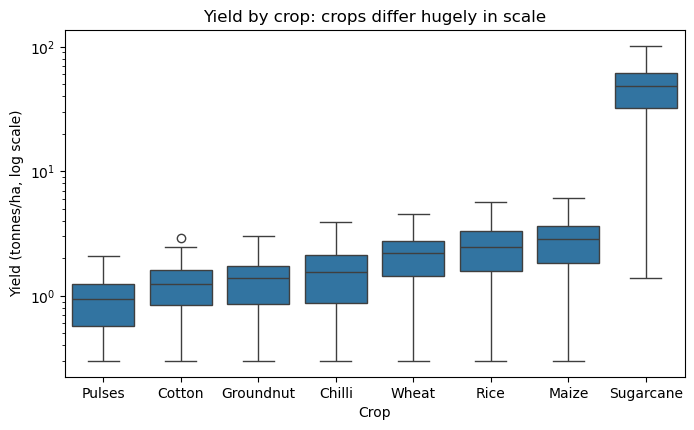

In [18]:
fig = audit_plots.fig_yield_by_crop(df_raw); plt.show()

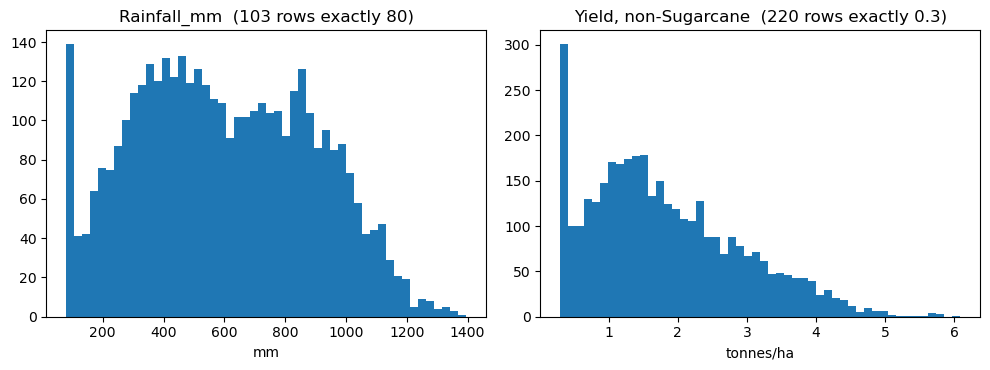

In [19]:
fig = audit_plots.fig_floor_pileups(df_raw); plt.show()

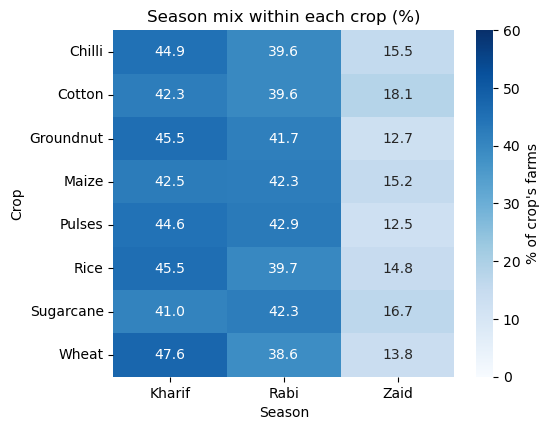

In [20]:
fig = audit_plots.fig_crop_season_heatmap(df_raw); plt.show()

## 4. Formula checks (derived columns)
Tolerances follow the stored decimals: Production has 2 decimals (max rounding error 0.005), Water efficiency has 3 decimals (0.0005).

In [21]:
audit['formula_checks'].round(4)

,rows_tested,within_tolerance,tolerance,max_abs_diff,note,pct_within_tolerance
formula,,,,,,
Production = Yield x Area,3968,3968,0.0050,0.0050,"Yield missing in 32 rows, so those rows cannot...",100.0000
Revenue = round(Production x Price),4000,4000,0.0000,0.0000,uses the stored (rounded) Production column,100.0000
Revenue = (Yield x Area) x Price [alt.],3968,216,1.0000,635.3750,"tolerance 1 INR; fails for most rows, so Reven...",5.4435
Profit = Revenue - Total_Cost,4000,4000,0.0000,0.0000,,100.0000
Water_Eff = Production / Water_Used x 1000,4000,4000,0.0005,0.0005,,100.0000


In [22]:
audit['recoverable_yield_check']

,value
rows with Yield missing,32.000000
...of which Production and Area are present,32.000000
recovery error on known rows: mean,0.000579
recovery error on known rows: max,0.010000


## 5. Summary of what Phase 1 established
# KrishiDrishti: Verified Findings Log

This file is updated after each phase. Only things that were actually computed from the data are recorded.

**Evidence labels** (every entry must carry one):
- `[OBSERVED]` a value read directly from the dataset
- `[DERIVED]` a metric we calculated from dataset columns
- `[MODEL]` a model prediction or model-based estimate (never causal)
- `[ASSUMPTION]` an external assumption, not in the dataset
- `[RECOMMENDATION]` a suggestion that follows from the evidence above

---

## Phase 0: Setup & environment

| # | Label | Finding | How verified |
|---|-------|---------|--------------|
| 0.1 | [OBSERVED] | Raw CSV has 4,000 rows x 28 columns | `pd.read_csv(...).shape` |
| 0.2 | [OBSERVED] | All 28 column names match the project spec, in the same order | `check_shape_and_columns()` in `src/data_loader.py` |
| 0.3 | [OBSERVED] | Raw file SHA-256: `fe17b9752e998a7463e5ac2e1e03f6d8c781be3541aaa3e422442ff1bb455c43` | `sha256sum`; saved in `data/raw/SHA256.txt` |

No data-quality, seasonal, or model findings exist yet.

## Phase 1: Data audit (read-only; nothing was cleaned or modified)

Raw file checksum re-verified after the audit (unchanged). Tables: `outputs/tables/p1_*.csv`. Figures: `outputs/figures/p1_*.png`. Code: `src/audit.py`.

### A. Structure and quality
| # | Label | Finding |
|---|-------|---------|
| 1.1 | [OBSERVED] | 17 float, 5 int and 6 text columns. No duplicate rows (full-row, Farm_ID, or ignoring Farm_ID). Farm_ID runs SF10001-SF14000 with no gaps. No stray spaces or case-variant labels in any text column. |
| 1.2 | [OBSERVED] | Only 3 columns have missing values: Rainfall_mm 48 (1.2%), Soil_Moisture_pct 40 (1.0%), Yield_Tonnes_Ha 32 (0.8%). Each affected row has exactly one missing cell: 120 rows (3.0%) in total. |
| 1.3 | [DERIVED] | Missingness looks close to random but this is not proven. 75 tests were run; 9 gave p<0.05 (about 3.8 expected by chance), 2 gave p<0.01, and none pass a Bonferroni threshold (smallest p = 0.0028 vs 0.00067). 5 of the 9 involve Yield-missing rows (only 32 rows, so low power). Evidence is weak either way. |
| 1.4 | [OBSERVED] | No negative values except Profit_INR (1,966 of 4,000 rows, 49.2%, are negative). No zeros anywhere. Humidity, Soil_Moisture and Disease_Pest_Risk are all within 0-100. |

### B. Formula checks (mathematical identities in the data)
| # | Label | Finding |
|---|-------|---------|
| 1.5 | [DERIVED] | **Production = Yield x Area** holds in 3,968 / 3,968 testable rows (100%), within the 0.005 rounding error of a 2-decimal Production column. (32 rows have no Yield, so cannot be tested.) |
| 1.6 | [DERIVED] | **Revenue = round(Production x Price)** holds exactly in 4,000 / 4,000 rows using the STORED (2-decimal) Production. Using un-rounded Yield x Area x Price instead, only 216 / 3,968 rows (5.4%) fall within 1 INR. So Revenue is built from the rounded Production column. |
| 1.7 | [DERIVED] | **Profit = Revenue - Total_Cost** holds exactly in 4,000 / 4,000 rows. |
| 1.8 | [DERIVED] | **Water_Efficiency = Production / Water_Used x 1000** holds within 0.0005 (3-decimal rounding) in 4,000 / 4,000 rows. |
| 1.9 | [DERIVED] | The 32 missing Yield values could be recovered as Production / Area: on rows where Yield is known, this recovery differs from the stored Yield by 0.0006 on average and 0.01 at most. **Not applied.** |

### C. Categories
| # | Label | Finding |
|---|-------|---------|
| 1.10 | [OBSERVED] | **All 10 districts appear under all 8 states** (every State x District cell has 34-71 farms; none are empty). For example, Rajkot appears under Punjab and Ludhiana under Tamil Nadu. |
| 1.10b | [ASSUMPTION] | External knowledge: in reality each district belongs to one state. So District is not a genuine sub-division of State in this file. |
| 1.11 | [OBSERVED] | Season counts: Kharif 1,779 (44.5%), Rabi 1,627 (40.7%), Zaid 594 (14.9%). Every crop appears in all 3 seasons. |
| 1.12 | [DERIVED] | Crop mix does not differ detectably across seasons: chi-square = 13.93, dof = 14, p = 0.455. E.g. Wheat is 47.6% Kharif, 38.6% Rabi, 13.8% Zaid. |
| 1.12b | [ASSUMPTION] | External knowledge: Wheat is normally a Rabi crop in India, so Kharif-heavy Wheat is agronomically unusual. |

### D. Ranges and outliers
| # | Label | Finding |
|---|-------|---------|
| 1.13 | [OBSERVED] | **Values pile up exactly at the minimum.** Rainfall_mm = 80.0 in 103 rows (2.6%): 0 Kharif, 38 Rabi, 65 Zaid. Yield = 0.3 in 220 of 3,968 rows (5.5%), spread across Kharif 93 / Rabi 77 / Zaid 50, and none are Sugarcane (its minimum is 1.39). Smaller pile-ups also at Soil_pH = 5.2 (44 rows), Seed_Quality = 0.65 (53) and = 1.0 (73), Pesticide = 0.5 (51), Fertilizer = 40 (33). |
| 1.13b | [DERIVED] | This pattern is consistent with values being clipped at a lower limit (the true value may be lower than the recorded one). This is an inference from the histograms, not confirmed by any documentation. |
| 1.14 | [DERIVED] | **Most "outliers" are crop scale, not errors.** Yield has 302 IQR outliers overall (7.55%) but only 1 within crop, because Sugarcane averages 46.9 t/ha (max 101.44) versus 0.9-2.7 t/ha for the other crops. Same effect for Water_Used (276 -> 5) and Production (333 -> 31). Profit stays high within crop (404 -> 201), i.e. it is genuinely skewed. |
| 1.15 | [OBSERVED] | Prices differ enormously by crop: mean about 3,490 INR/t for Sugarcane, 20,991 Maize, 22,023 Rice, 23,829 Wheat, 56,310 Groundnut, 67,921 Cotton, 71,432 Pulses, 103,373 Chilli. |
| 1.16 | [DERIVED] | **Cost per hectare is almost identical across crops** (mean 66,056-67,089 INR/ha for all 8 crops). Combined with 1.15, the share of farms with negative profit is: Wheat 74.1%, Rice 66.4%, Maize 63.7%, Pulses 49.2%, Groundnut 40.8%, Cotton 34.6%, Chilli 18.0%, Sugarcane 11.5%. |
| 1.17 | [OBSERVED] | Water_Used per hectare is not zero for Rainfed farms: mean 446 m3/ha (Drip 727, Sprinkler 795, Flood 1,029). |

### E. Implications for later phases (nothing applied yet)
| # | Label | Suggestion |
|---|-------|------------|
| 1.18 | [RECOMMENDATION] | **Leakage (decide in Phase 7):** with Yield as the target, Production, Revenue, Profit and Water_Efficiency are all exact functions of Yield (given Area, Price, Cost), so they should be excluded as predictors. Total_Cost is not an exact function of anything tested, but cost per hectare is nearly constant, so it should be examined before being used. |
| 1.19 | [RECOMMENDATION] | Missing values (Phase 2): decide between recovering Yield from Production / Area or dropping those 32 rows, and how to handle Rainfall / Soil_Moisture. Any imputation for ML should happen inside the cross-validation pipeline to avoid leakage. |
| 1.20 | [RECOMMENDATION] | Do not treat District as nested inside State until the data source is clarified (see 1.10). |
| 1.21 | [RECOMMENDATION] | Because of the yield floor (1.13), report the share of rows at 0.3 when presenting yield models, and be careful with conclusions about the lowest-yield farms. |

---

## Change log (overwrites / important revisions)

| Date | Phase | What changed | Why |
|------|-------|--------------|-----|
| 2026-09-20 | 0 | File created | Project setup |
| 2026-09-20 | 1 | Added `src/audit.py`, `src/audit_plots.py`, `scripts/run_phase1.py`; filled `notebooks/01_data_audit.ipynb`; created `outputs/tables/p1_*.csv` and `outputs/figures/p1_*.png`. Runner was executed twice; the second run regenerated the same Phase 1 outputs (overwrite=True) after extra tables were added. Values were identical. | Phase 1 audit |


In [ ]:
from scipy.stats import kruskal

groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in df.groupby("Irrigation_Method")
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis statistic: {stat:.3f}")
print(f"p-value: {p_value:.6f}")

Kruskal-Wallis statistic: 22.439
p-value: 0.000053
